In [1]:
import jax
import jax.numpy as jnp
import jax.random as jr
import matplotlib.pyplot as plt

from jax import vmap, lax

from tensorflow_probability.substrates import jax as tfp
tfd = tfp.distributions

from hmfc.model import HierarchicalBernoulliLDS
from hmfc.gibbs import gibbs_step


In [2]:
# def simulate_one_dataset(key, true_model, num_subjects, num_trials, num_inputs, true_a, true_nu_a, true_alpha, true_beta, true_nu_mu0):

#     # Sample inputs
#     inputs = tfd.Normal(0, 1).sample(sample_shape=(num_subjects, num_trials, num_inputs), seed=key)

#     # NO LONGER INCLUDE AN INTERCEPT TERM!
#     # inputs = inputs.at[:, :, 0].set(1.0)

#     # REQUIRE THAT INPUTS ARE MEAN ZERO
#     inputs -= inputs.mean(axis=0)

#     # Sample true params, states, and emissions
#     true_params, true_states, emissions = true_model.sample(key, inputs)
#     masks = jnp.ones_like(emissions)

#     """
#     Problem: if absolute value of true_states for a subject exceeds crit_value, then sigmoid becomes saturated.
#     This is very hard for the model to recover so we'll resample the true_states for these problematic subjects with
#     their original true_params. If we can't find abs(true_states) > 10 within max_iter iterations, we resample a_i and sigmasq_i.
#     """
#     crit_value = 9
#     max_iter = 50


#     bad_subjects = jnp.where(jnp.max(abs(true_states),axis=1) > crit_value)[0] # check for each subject the absolute true_states exceed crit_value

#     if bad_subjects.size > 0:
#         for subj in bad_subjects:
#             print(subj)
#             # Call the true params and input from bad subject
#             x_i = true_states[subj]
#             u_i = inputs[subj]

#             w_i = true_params['w'][subj]
#             a_i = true_params['a'][subj]
#             sigmasq_i = true_params['sigmasq'][subj]
#             mu0_i = true_params['mu0'][subj]

#             # Resample true_states and emissions from true params and inputs
#             i = 0

#             while jnp.any(jnp.abs(x_i) > crit_value):

#                 key = jr.PRNGKey(i)
#                 k1, k2, k3, k4, k5, k6 = jr.split(key,6)


#                 # Sample latent states
#                 b_i = mu0_i * (1 - a_i)
#                 sigmasq0_i = 1
                
#                 x_i0 = tfd.Normal(mu0_i, jnp.sqrt(sigmasq0_i)).sample(seed=k1)
#                 def _step(x_it, key):
#                     x_itp1 = tfd.Normal(a_i * x_it + b_i, jnp.sqrt(sigmasq_i)).sample(seed=key)
#                     return x_itp1, x_it
#                 _, x_i = lax.scan(_step, x_i0, jr.split(k2, num_trials))


#                 # Sample emissions
#                 y_i = tfd.Bernoulli(x_i + u_i @ w_i).sample(seed=k3)

#                 i=i+1 # change seed for key

#                 if i == max_iter: # if stuck in a loop, resample parameters
#                     # sample new params
#                     print('new params sampled!')
#                     a_i = tfd.TruncatedNormal(true_a,
#                                               true_nu_a,
#                                               0.0, A_MAX).sample(seed=k4)

#                     sigmasq_i = tfd.InverseGamma(true_alpha,
#                                                  true_beta).sample(seed=k5)

#                     mu0_i = tfd.Normal(0, true_nu_mu0).sample(seed=k6)

#                     # save new params
#                     true_params['a'] = true_params['a'].at[subj].set(a_i)
#                     true_params['sigmasq'] = true_params['sigmasq'].at[subj].set(sigmasq_i)
#                     true_params['mu0'] = true_params['mu0'].at[subj].set(mu0_i)

#             # Save new true_states and emissions

#             true_states = true_states.at[subj].set(x_i)
#             emissions = emissions.at[subj].set(y_i)


#     return true_params, true_states, emissions, inputs, masks

## Simulate from the model

In [3]:
# Sample dataset
key = jr.PRNGKey(0)

num_subjects = 3
num_trials = 10
num_iters = 10000
num_inputs = 2

true_a0 = 0.98
true_nu_a0 = 0.025
true_w0 = jnp.array([0.0, 0.2])
true_nu_w0 = jnp.array([1.0, 1.0])
true_mu_sigmasq = 0.1**2
true_beta_sigmasq = 0.1**2
true_nu_mu0 = 0.25

# Create our true model
true_model = HierarchicalBernoulliLDS(num_inputs,
                                      a_0=true_a0, 
                                      nu_a=true_nu_a0, 
                                      w_0=true_w0, 
                                      nu_w=true_nu_w0, 
                                      mu_sigmasq=true_mu_sigmasq,
                                      beta_sigmasq=true_beta_sigmasq, 
                                      nu_mu0=true_nu_mu0)

# Sample inputs
inputs = tfd.Normal(0, 1).sample(sample_shape=(num_subjects, num_trials, num_inputs), seed=key)

# REQUIRE THAT INPUTS ARE MEAN ZERO
inputs -= inputs.mean(axis=0)

# Sample true params, states, and emissions
true_params, true_states, emissions = true_model.sample(key, inputs)
masks = jnp.ones_like(emissions)

## Initialize a new model for fitting the data

In [4]:

# Initialize model
init_a0 = 0.90
init_nu_a0 = 0.1
init_w0 = jnp.zeros(num_inputs)
init_nu_w0 = jnp.repeat(1.0, num_inputs)
init_mu_sigmasq = 0.1**2
init_beta_sigmasq = 0.1**2
init_nu_mu0 = true_nu_mu0

# Create our true model
model = HierarchicalBernoulliLDS(num_inputs,
                                 a_0=init_a0, 
                                 nu_a=init_nu_a0, 
                                 w_0=init_w0, 
                                 nu_w=init_nu_w0, 
                                 mu_sigmasq=init_mu_sigmasq,
                                 beta_sigmasq=init_beta_sigmasq, 
                                 nu_mu0=init_nu_mu0)

params, states, _ = model.sample(key, inputs)

## Run the Geweke Test

In [5]:
def geweke_step(carry, key):
    model, params, emissions, states = carry
    
    # Perform one Gibbs step
    this_key, key = jr.split(key)
    lp, states, params, model = gibbs_step(this_key, emissions, masks, states, inputs, params, model,
                                           update_global_weights=False,
                                           update_global_ar=False,
                                           update_global_ar_var=False)

    # Sample new emissions for the Geweke step
    def _sample_emissions(key, params, states, inputs):
        return tfd.Bernoulli(states + inputs @ params['w']).sample(seed=key)
    emissions = vmap(_sample_emissions)(jr.split(key, num_subjects), params, states, inputs)

    # Extract outputs
    output = (lp, model, params, emissions, states)
    new_carry = (model, params, emissions, states)
    return new_carry, output


init_carry = (model, params, emissions, states)
_, samples = lax.scan(geweke_step, init_carry, jr.split(key, num_iters))
(lps, model_samples, params_samples, emissions_samples, states_samples) = samples
jax.block_until_ready(lps)

Array([ 36.751873,  58.53463 ,  46.150913, ..., -19.099081, -21.85349 ,
       -32.468845], dtype=float32)

## Compare samples to the prior

Text(0, 0.5, 'log joint probability')

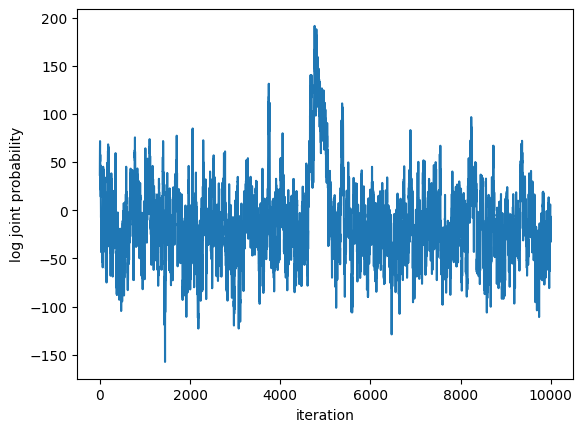

In [6]:
plt.plot(lps)
plt.xlabel("iteration")
plt.ylabel("log joint probability")

In [7]:
model_samples

HierarchicalBernoulliLDS(
  log_lambda_mu=weak_f32[10000],
  log_lambda_beta=weak_f32[10000],
  w_0=f32[10000,2],
  log_nu_w=weak_f32[10000,2],
  logit_a_0=weak_f32[10000],
  log_nu_a=weak_f32[10000],
  log_nu_mu0=weak_f32[10000],
  log_mu_sigmasq=f32[10000],
  log_beta_sigmasq=f32[10000]
)

### Check log $\mu_{\sigma^2}$

Text(0, 0.5, '$p(\\log \\mu)$')

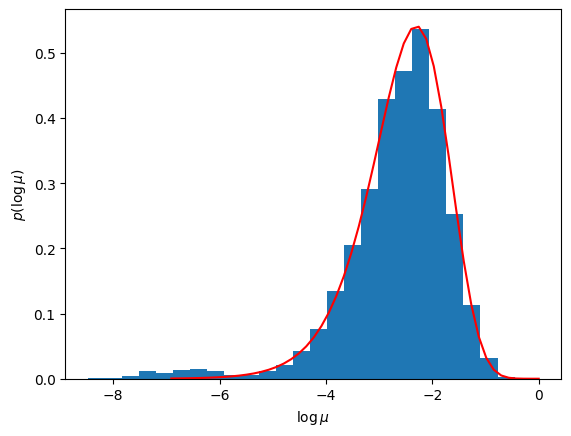

In [14]:
log_mu_vals = jnp.linspace(jnp.log(0.001), jnp.log(1.0))
p_log_mu = tfd.TransformedDistribution(
            tfd.Gamma(2.0, 2.0 * model.lambda_mu),
            tfp.bijectors.Log(),
        )
plt.hist(model_samples.log_mu_sigmasq.ravel(), 25, density=True)
plt.plot(log_mu_vals, jnp.exp(p_log_mu.log_prob(log_mu_vals)), '-r')
plt.xlabel(r"$\log \mu$")
plt.ylabel(r"$p(\log \mu)$")

### Check $\log \beta$

Text(0, 0.5, '$p(\\log \\beta)$')

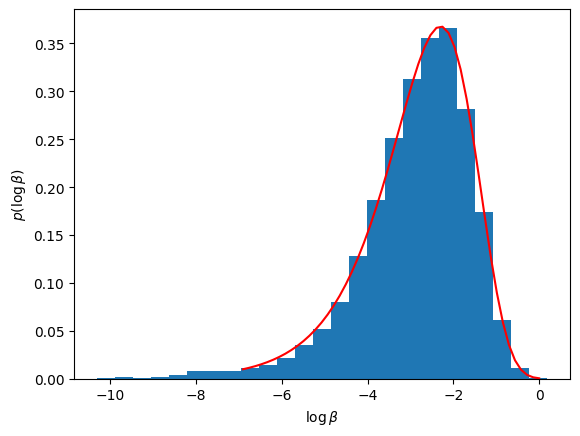

In [9]:
log_beta_vals = jnp.linspace(jnp.log(0.001), jnp.log(1.0))
p_log_beta = tfd.TransformedDistribution(
            tfd.Exponential(model.lambda_beta),
            tfp.bijectors.Log(),
        )
plt.hist(model_samples.log_beta_sigmasq.ravel(), 25, density=True)
plt.plot(log_beta_vals, jnp.exp(p_log_beta.log_prob(log_beta_vals)), '-r')
plt.xlabel(r"$\log \beta$")
plt.ylabel(r"$p(\log \beta)$")

### Check per-subject weights

Since $w_0 = 0$ and $nu_w = 1$, the per subject weights are distributed as, $w_i \sim \mathrm{N}(0,1)$. 

Text(0, 0.5, '$p(w)$')

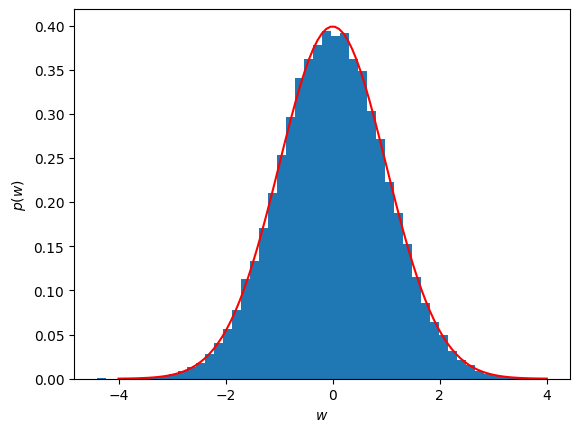

In [10]:
p_w = tfd.Normal(0, 1)
w_vals = jnp.linspace(-4, 4, 100)

plt.hist(params_samples['w'].ravel(), 50, density=True)
plt.plot(w_vals, jnp.exp(p_w.log_prob(w_vals)), '-r')
plt.xlabel(r"$w$")
plt.ylabel(r"$p(w)$")

### Check per-subject dynamics coefficient

Under the prior,
\begin{align*}
a_i &\sim \mathrm{TruncNorm}(a_0, \nu_a^2; [0, a_{\mathsf{max}}])
\end{align*}

Text(0, 0.5, '$p(a)$')

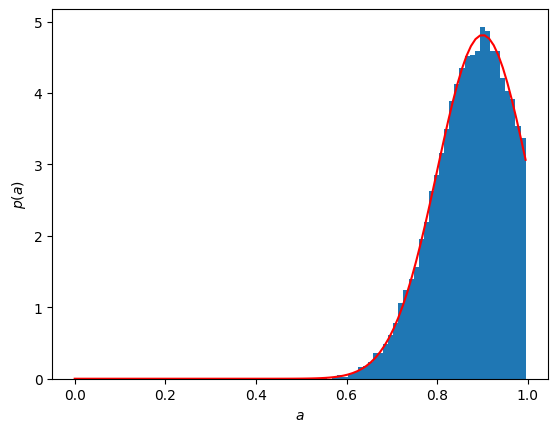

In [11]:
from jax.nn import sigmoid
from hmfc.constants import A_MAX

p_a = tfd.TruncatedNormal(sigmoid(model.logit_a_0), jnp.exp(model.log_nu_a), 0.0, A_MAX)
a_vals = jnp.linspace(0, A_MAX, 100)

plt.hist(params_samples['a'].ravel(), 50, density=True)
plt.plot(a_vals, jnp.exp(p_a.log_prob(a_vals)), '-r')
plt.xlabel(r"$a$")
plt.ylabel(r"$p(a)$")

### Check per-subject bias


Text(0, 0.5, '$p(\\mu_0)$')

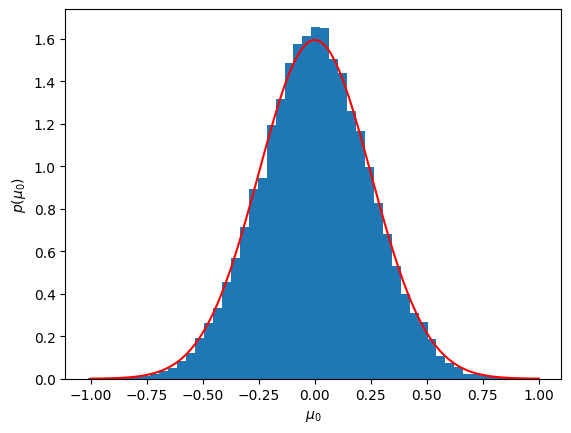

In [12]:
p_mu0 = tfd.Normal(0.0, jnp.exp(model.log_nu_mu0))
mu0_vals = jnp.linspace(-1, 1, 100)

plt.hist(params_samples['mu0'].ravel(), 50, density=True)
plt.plot(mu0_vals, jnp.exp(p_mu0.log_prob(mu0_vals)), '-r')
plt.xlabel(r"$\mu_0$")
plt.ylabel(r"$p(\mu_0)$")

### Check per-subject dynamics variance

Text(0, 0.5, '$p(\\sigma^2)$')

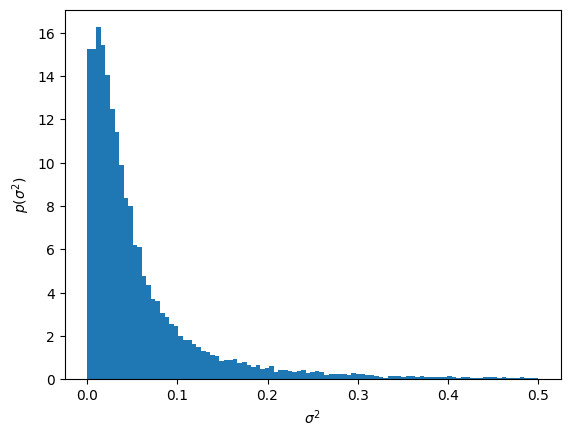

In [15]:
# p_sigmasq = tfd.InverseGamma(jnp.exp(model.log_alpha), jnp.exp(model.log_beta))
sigmasq_values = jnp.linspace(0, 0.5, 100)

plt.hist(params_samples['sigmasq'].ravel(), sigmasq_values, density=True)
# plt.plot(sigmasq_values, jnp.exp(p_sigmasq.log_prob(sigmasq_values)), '-r')
plt.xlabel(r"$\sigma^2$")
plt.ylabel(r"$p(\sigma^2)$")
# plt.xlim(0,1)